### Objective
- Is the data clean?
- Are there missing values?
- Are there duplicates?
- What are the distributions?
- Which variables look important?
- Are there obvious relationships?
- What business patterns can we already observe?

**DATA IMPORT AND EDA**

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('../data/processed/master_dataset.csv',sep=';')
df.head()

,performance_id,interaction_date,campaign_id,customer_id,factor_id,spend,impressions,reach,frequency,clicks,...,city,state,gender,age_group,audience_segment,weather,holiday_flag,festival_flag,competitor_spend,discount_percentage
0,MP00000001,2025-12-26,CA029,CU00042179,EF726,2808,9206,5166,1.78,242,...,Hyderabad,Telangana,Male,35-44,Young Professionals,Cloudy,No,No,711998,10
1,MP00000002,2025-04-13,CA100,CU00023874,EF469,7499,47764,44339,1.08,600,...,Hyderabad,Telangana,Female,25-34,Parents,Sunny,No,No,244044,10
2,MP00000003,2025-12-17,CA041,CU00022611,EF717,8098,31756,27820,1.14,1003,...,Bangalore,Karnataka,Female,45-54,Gamers,Sunny,No,No,691225,0
3,MP00000004,2025-02-11,CA097,CU00006368,EF408,1441,5650,3780,1.49,393,...,Kolkata,West Bengal,Female,18-24,Parents,Sunny,No,No,492363,10
4,MP00000005,2025-09-23,CA077,CU00018756,EF632,6101,21184,13012,1.63,913,...,Mumbai,Maharashtra,Male,35-44,Young Professionals,Rainy,No,No,740209,10


In [55]:
df.shape

(500000, 32)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   performance_id       500000 non-null  object 
 1   interaction_date     500000 non-null  object 
 2   campaign_id          500000 non-null  object 
 3   customer_id          500000 non-null  object 
 4   factor_id            500000 non-null  object 
 5   spend                500000 non-null  int64  
 6   impressions          500000 non-null  int64  
 7   reach                500000 non-null  int64  
 8   frequency            500000 non-null  float64
 9   clicks               500000 non-null  int64  
 10  conversions          500000 non-null  int64  
 11  revenue              500000 non-null  int64  
 12  campaign_name        500000 non-null  object 
 13  campaign_type        500000 non-null  object 
 14  brand                500000 non-null  object 
 15  product_category 

In [57]:
df.describe()

,spend,impressions,reach,frequency,clicks,conversions,revenue,campaign_budget,competitor_spend,discount_percentage
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,5.000000e+05,500000.000000,500000.000000,500000.000000
mean,6346.325816,24268.948486,18886.602486,1.317493,874.593256,45.013590,2.004753e+05,346391.033198,409249.764012,11.598780
std,4962.582884,20656.627117,16306.673272,0.205834,717.433387,44.337069,2.238865e+05,197813.173311,170171.538935,8.924531
min,778.000000,1793.000000,1019.000000,1.000000,63.000000,1.000000,2.399000e+03,84932.000000,150875.000000,0.000000
25%,2546.000000,9296.000000,7136.000000,1.150000,406.000000,15.000000,5.465200e+04,159036.000000,271080.000000,5.000000
50%,4954.000000,18053.000000,13906.000000,1.290000,653.000000,31.000000,1.262080e+05,309641.000000,387058.000000,10.000000
75%,8988.000000,32984.000000,25610.000000,1.470000,1104.000000,59.000000,2.615400e+05,517089.000000,502466.000000,15.000000
max,42703.000000,256963.000000,216395.000000,1.850000,10898.000000,724.000000,3.412287e+06,804345.000000,795112.000000,40.000000


In [58]:
df.describe(include='object')

,performance_id,interaction_date,campaign_id,customer_id,factor_id,campaign_name,campaign_type,brand,product_category,campaign_status,...,channel_name,channel_type,city,state,gender,age_group,audience_segment,weather,holiday_flag,festival_flag
count,500000,500000,500000,500000,500000,500000,500000,500000,500000,500000,...,500000,500000,500000,500000,500000,500000,500000,500000,500000,500000
unique,500000,730,100,49997,730,28,6,5,3,2,...,8,6,7,6,2,5,6,3,2,2
top,MP00000001,2025-12-31,CA008,CU00008605,EF731,Reebok Lead Generation,Brand Awareness,Reebok,Apparel,Completed,...,Facebook,Social,Chennai,Maharashtra,Male,25-34,Young Professionals,Sunny,No,No
freq,1,2227,5328,25,2227,39873,95987,119625,185527,429990,...,115956,180449,72561,142469,276194,177456,148542,195377,469426,457135


**DATA PREPROCESSING**

In [59]:
df.isnull().sum()

performance_id         0
interaction_date       0
campaign_id            0
customer_id            0
factor_id              0
spend                  0
impressions            0
reach                  0
frequency              0
clicks                 0
conversions            0
revenue                0
campaign_name          0
campaign_type          0
brand                  0
product_category       0
campaign_budget        0
campaign_status        0
campaign_start_date    0
campaign_end_date      0
channel_name           0
channel_type           0
city                   0
state                  0
gender                 0
age_group              0
audience_segment       0
weather                0
holiday_flag           0
festival_flag          0
competitor_spend       0
discount_percentage    0
dtype: int64

In [60]:
df.duplicated().sum()

np.int64(0)

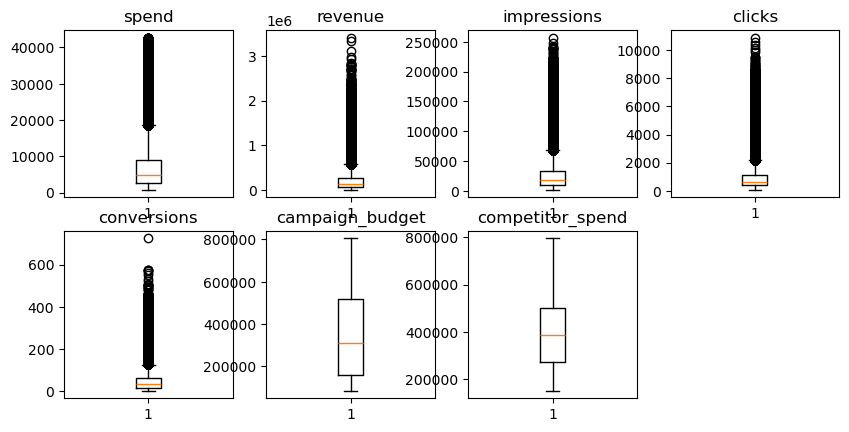

In [61]:
cols=['spend','revenue','impressions','clicks','conversions','campaign_budget','competitor_spend',]
fig,ax=plt.subplots(4,4,figsize=(10,10))
ax=ax.ravel()

for i,col in enumerate(cols):
    ax[i].boxplot(df[col])
    ax[i].set_title(col)

for i in range(len(cols),len(ax)):
    fig.delaxes(ax[i])

In [62]:
cols2=['spend','revenue','impressions','clicks','conversions']

for i in cols2:
    Q1=df[i].quantile(0.25)
    Q3=df[i].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    
    if ((df[i]>upper) | (df[i]<lower)).any():
        print('outlier found in ',i)

    df[i]=df[i].clip(lower=lower,upper=upper)
    print(f'Outlier in {i} has been capped')

outlier found in  spend
Outlier in spend has been capped
outlier found in  revenue
Outlier in revenue has been capped
outlier found in  impressions
Outlier in impressions has been capped
outlier found in  clicks
Outlier in clicks has been capped
outlier found in  conversions
Outlier in conversions has been capped


In [63]:
df.tail()

,performance_id,interaction_date,campaign_id,customer_id,factor_id,spend,impressions,reach,frequency,clicks,...,city,state,gender,age_group,audience_segment,weather,holiday_flag,festival_flag,competitor_spend,discount_percentage
499995,MP00499996,2024-08-18,CA076,CU00036570,EF231,9430,46915,30351,1.55,538,...,Chennai,Tamil Nadu,Female,35-44,Gamers,Sunny,No,No,156100,0
499996,MP00499997,2024-06-28,CA004,CU00009111,EF180,11590,68516,70033,1.05,2151,...,Bangalore,Karnataka,Male,45-54,Young Professionals,Cloudy,No,No,479420,5
499997,MP00499998,2025-12-02,CA014,CU00008189,EF702,2741,6374,3593,1.77,307,...,Delhi,Delhi,Male,25-34,Fitness Enthusiasts,Cloudy,No,No,516434,5
499998,MP00499999,2024-10-30,CA067,CU00035287,EF304,13793,38313,26291,1.46,1170,...,Chennai,Tamil Nadu,Female,35-44,Fitness Enthusiasts,Sunny,No,No,192239,5
499999,MP00500000,2024-03-21,CA001,CU00020759,EF081,6984,19346,17797,1.09,288,...,Delhi,Delhi,Male,35-44,Students,Cloudy,No,No,493374,5


In [64]:
df['CTR']=df['clicks']/df['impressions']
df['CVR']=df['conversions']/df['clicks']
df['CPC']=df['spend']/df['clicks']
df['CPA']=df['spend']/df['conversions']
df['ROAS']=df['revenue']/df['spend']

df['Profit']=df['revenue']-df['spend']

df['interaction_date']=pd.to_datetime(df['interaction_date'])
df['Month']=df['interaction_date'].dt.month_name()
df['Quarter']=df['interaction_date'].dt.quarter
df['Year']=df['interaction_date'].dt.year
df['Day_of_Week']=df['interaction_date'].dt.day_name()

df['weekend_flag']=np.where(df['interaction_date'].dt.dayofweek>=5,'Yes','No') #Monday->0 Sunday->6

df['campaign_start_date'] = pd.to_datetime(df['campaign_start_date'])
df['campaign_end_date'] = pd.to_datetime(df['campaign_end_date'])
df['campaign_duration']=(df['campaign_end_date']-df['campaign_start_date']).dt.days+1

df['budget_utilization']=(df['spend']/df['campaign_budget'])*100
df['high_competitor_spend_flag']=np.where(df['competitor_spend']>600000,'Yes','No')
df['high_discount_flag']=np.where(df['discount_percentage']>=20,'Yes','No')

In [65]:
df.tail()

,performance_id,interaction_date,campaign_id,customer_id,factor_id,spend,impressions,reach,frequency,clicks,...,Profit,Month,Quarter,Year,Day_of_Week,weekend_flag,campaign_duration,budget_utilization,high_competitor_spend_flag,high_discount_flag
499995,MP00499996,2024-08-18,CA076,CU00036570,EF231,9430,46915,30351,1.55,538,...,15074,August,3,2024,Sunday,Yes,46,2.010070,No,No
499996,MP00499997,2024-06-28,CA004,CU00009111,EF180,11590,68516,70033,1.05,2151,...,478459,June,2,2024,Friday,No,31,3.446430,No,No
499997,MP00499998,2025-12-02,CA014,CU00008189,EF702,2741,6374,3593,1.77,307,...,90307,December,4,2025,Tuesday,No,46,1.849628,No,No
499998,MP00499999,2024-10-30,CA067,CU00035287,EF304,13793,38313,26291,1.46,1170,...,187408,October,4,2024,Wednesday,No,46,1.850761,No,No
499999,MP00500000,2024-03-21,CA001,CU00020759,EF081,6984,19346,17797,1.09,288,...,4420,March,1,2024,Thursday,No,91,1.092891,No,No


**UNIVARIATE ANALYSIS**

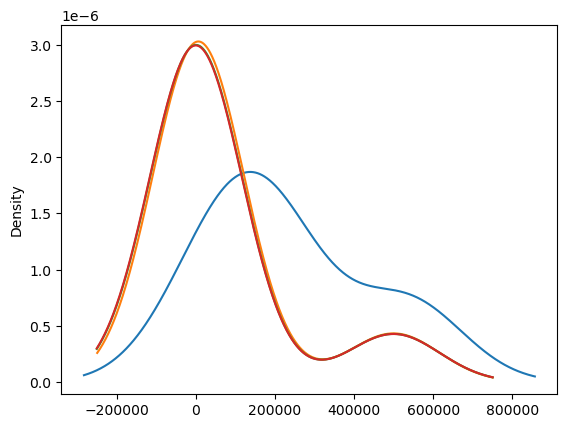

In [82]:
cols3=['revenue','spend','clicks','conversions','impressions','competitor_spend','discount_percentage']
for i in cols3[:4]:
    df[i].describe().plot(kind='kde')

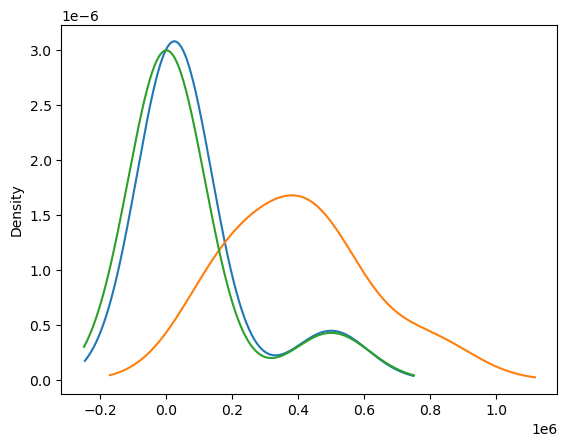

In [83]:
for i in cols3[4:]:
    df[i].describe().plot(kind='kde')

- All of the numerical fields are highly righ skewed.

**BI-VARIATE ANALYSIS**

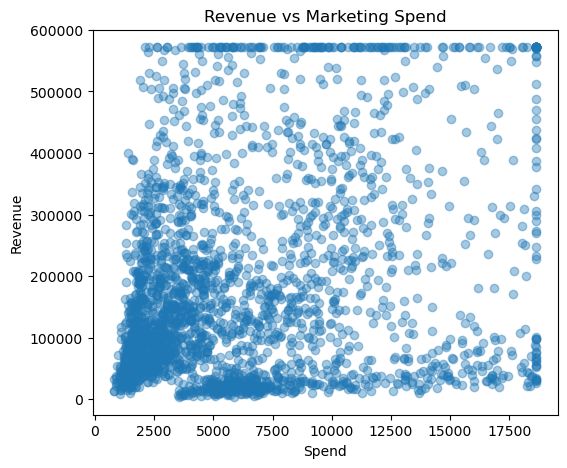

In [184]:
sample = df.sample(2500, random_state=42)

plt.figure(figsize=(6,5))
plt.scatter(sample["spend"], sample["revenue"], alpha=0.4)
plt.xlabel("Spend")
plt.ylabel("Revenue")
plt.title("Revenue vs Marketing Spend")
plt.show()


##### Key Insights: Revenue vs. Marketing Spend

* **Low Budget-to-Revenue Coupling:** Raw marketing spend is a poor predictor of revenue.
* **Operational Clustering:** The vast majority of campaigns cluster in the low-spend, low-revenue segment 
* **Data Boundary Capping:** The sharp horizontal line and vertical line at the limitsreflect cap limits introduced during data preprocessing (IQR outlier capping).

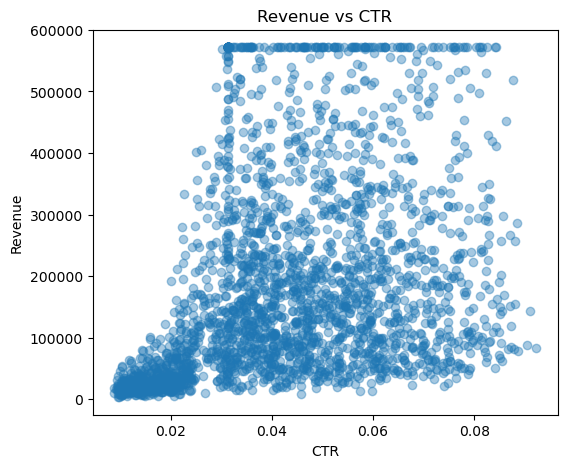

In [185]:
plt.figure(figsize=(6,5))
plt.scatter(sample["CTR"], sample["revenue"], alpha=0.4)
plt.xlabel("CTR")
plt.ylabel("Revenue")
plt.title("Revenue vs CTR")
plt.show()

##### Key Insights: Revenue vs. Scaled Spend

* **Non-Linear Trend & Wide Variance:** CTR shows weak linear alignment with revenue. 
* **Low-Spend Density Cluster:** A dense concentration of data points sits at the lower end of spend.
* **Upper Bound Capping:** The sharp horizontal line at confirms revenue capping/clipping from preprocessing, preventing extreme outliers from distorting downstream model training.

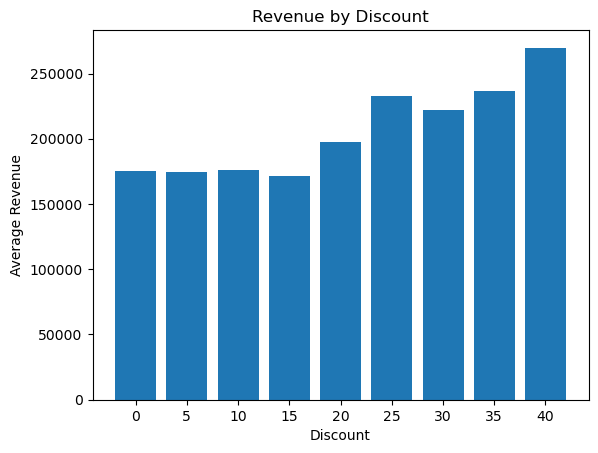

In [195]:
revenue_discount = (df.groupby("discount_percentage")["revenue"].mean().reset_index())
plt.bar(revenue_discount["discount_percentage"].astype(str),revenue_discount["revenue"])
plt.xlabel("Discount")
plt.ylabel("Average Revenue")
plt.title("Revenue by Discount")
plt.show()

##### Key Insights: Average Revenue by Discount Percentage

* **Highest Campaign Yield at 40% Discount:** Average revenue per campaign peaks at **40% discount**, delivering the highest individual campaign yield in the dataset.
* **Positive Trend Across Higher Tiers:** Average revenue shows a clear upward trajectory once discounts reach **20% and above** , compared to the lower baseline of 0%–15%.
* **Flat Low-Discount Baseline:** Discounts between **0% and 15%** generate nearly flat average revenue (~$170k–$175k), indicating that small promotional discounts don't meaningfully impact campaign size or unit yield.

<Axes: xlabel='channel_name'>

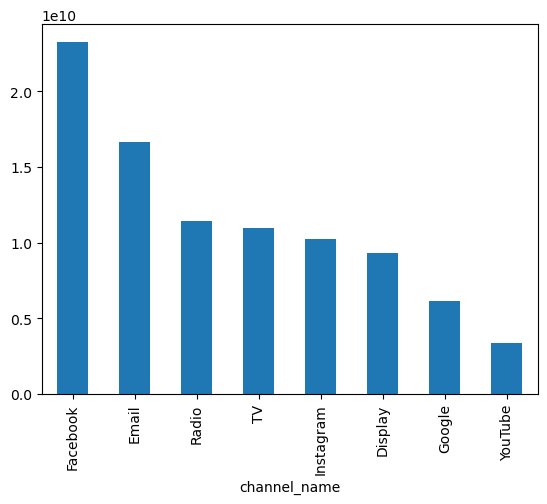

In [145]:
revenue_channel=df.groupby('channel_name')['revenue'].sum().sort_values(ascending=False).plot(kind='bar')
revenue_channel

##### Key Insights: Revenue by Marketing Channel

* **Dominant Core Channels:** **Facebook** is by far the top revenue driver (>2.3B), followed by **Email** (~1.6B). Combined, these two lead all other marketing touchpoints by a significant margin.
* **Consistent Middle Tier:** **Radio, TV, Instagram, and Display** show steady, comparable revenue generation, each contributing roughly 0.9B–1.1B to overall performance.
* **Underperforming Digital Channels:** **Google** and **YouTube** generate the lowest revenue among all channels, indicating either lower ad spend allocation or poorer conversion efficiency on search and video formats.

<Axes: xlabel='campaign_type'>

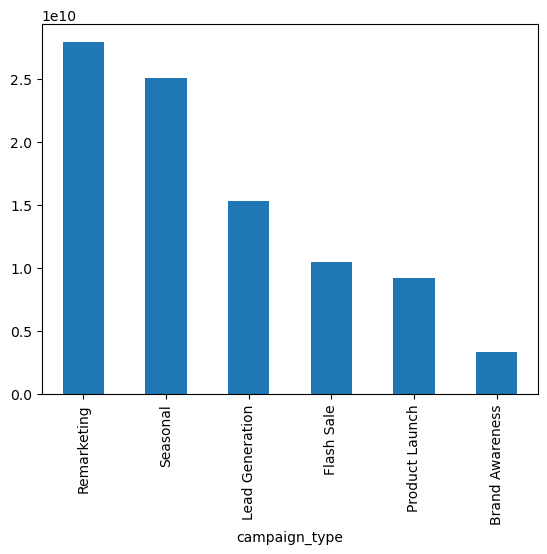

In [146]:
revenue_campaign=df.groupby('campaign_type')['revenue'].sum().sort_values(ascending=False).plot(kind='bar')
revenue_campaign

##### Key Insights: Revenue by Campaign Type

* **High-Intent Drives Highest Returns:** **Remarketing** and **Seasonal** campaigns dominate revenue generation, proving that targeting existing leads and leveraging seasonal demand are the most effective revenue drivers.
* **Mid-Funnel Stability:** **Lead Generation**, **Flash Sale**, and **Product Launch** form a steady secondary tier (0.9B–1.5B), contributing solid mid-funnel conversion value.
* **Top-of-Funnel Lag:** **Brand Awareness** generates the lowest direct revenue, which aligns with top-of-funnel goals focused on reach rather than immediate sales conversions.

<Axes: xlabel='audience_segment'>

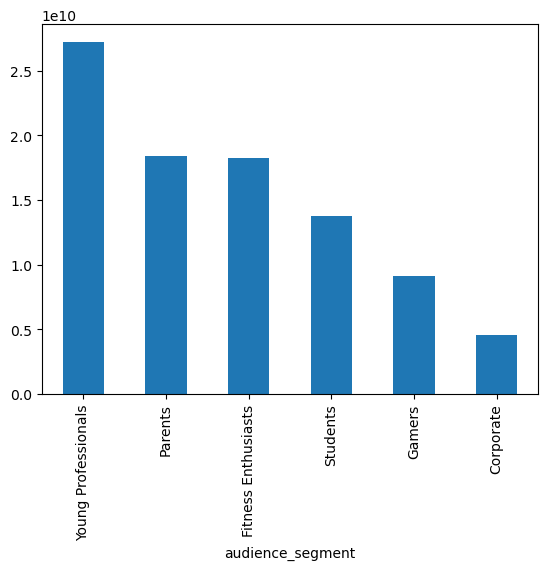

In [147]:
revenue_audience_segment=df.groupby('audience_segment')['revenue'].sum().sort_values(ascending=False).plot(kind='bar')
revenue_audience_segment

##### Key Insights: Revenue by Audience Segment

* **Primary Value Driver:** **Young Professionals** represent the top-performing customer segment by a massive margin.
* **Strong Secondary Base:** **Parents** and **Fitness Enthusiasts** form a highly reliable second tier, generating nearly identical revenue.
* **Niche Audience Trailing:** **Gamers**and **Corporate** account for the lowest total revenue, indicating either lower overall reach or lower purchasing frequency among B2B/corporate buyers.

<Axes: xlabel='weather'>

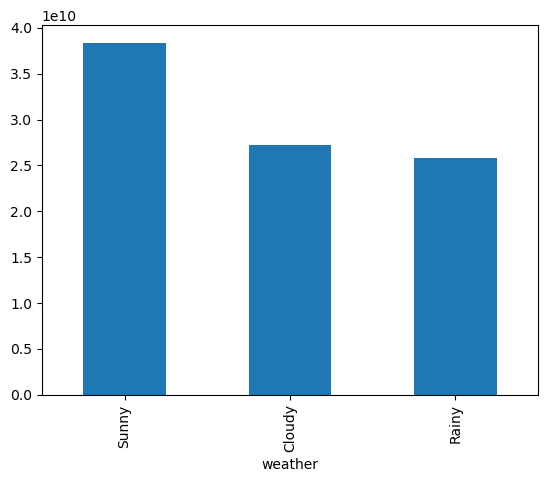

In [148]:
revenue_weather=df.groupby('weather')['revenue'].sum().sort_values(ascending=False).plot(kind='bar')
revenue_weather

##### Key Insights: Revenue by Weather Condition

* **Sunny Weather Outperforms:** **Sunny** days generate substantially higher total revenue.
* **Comparable Secondary Conditions:** Revenue during **Cloudy**and **Rainy**days is nearly identical, showing consistent consumer purchasing performance despite adverse weather.
* **Weather-Driven Lift:** Clear, sunny conditions provide roughly a **40% revenue boost** over cloudy and rainy days, highlighting potential opportunities for weather-triggered ad bidding strategies.

<Axes: >

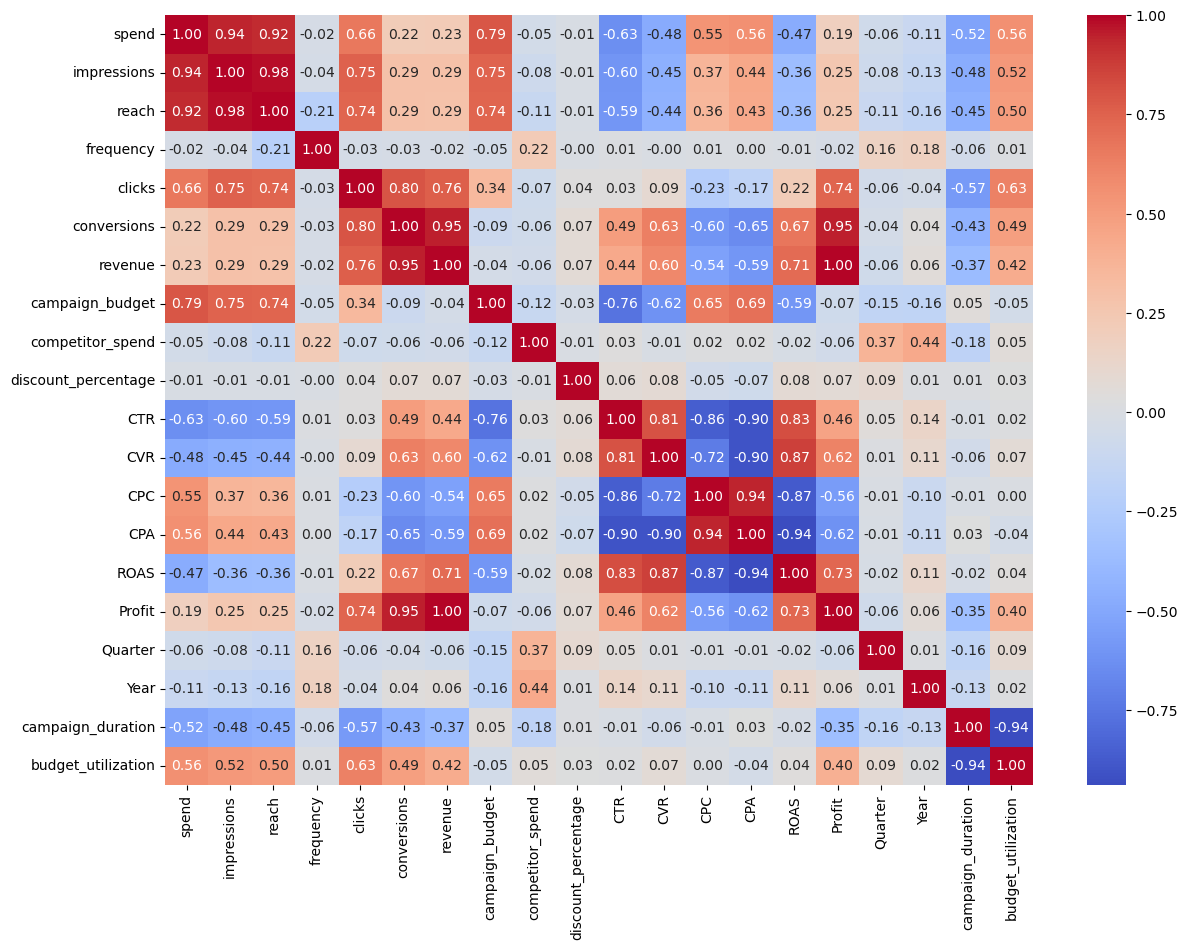

In [99]:
corr=df.corr(method='spearman',numeric_only=True)
import seaborn as sns
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm',fmt='.2f')

##### Key Insights: Feature Correlation Analysis

* **Conversion & Revenue Funnel:** **Conversions** share near-perfect positive correlation with **Revenue** and **Profit**. **Clicks** strongly drive **Conversions** confirming the core digital funnel operates as expected.
* **Efficiency vs. Cost Drivers:** **ROAS** is strongly boosted by   **CVR** and **CTR**, while severe cost penalties exist:   **CPC** ($-0.87$) and **CPA** ($-0.94$) heavily degrade ad profitability.
* **Spend Disconnect:** **Spend** correlates strongly with **Impressions** and **Reach**, but has a very weak correlation with **Revenue** and **Profit**. 
* **Operational Bottlenecks:** **Campaign Duration** shows a strong inverse correlation with **Budget Utilization** ($-0.94$), indicating longer campaigns struggle significantly with budget pacing efficiency compared to shorter campaigns.

In [198]:
df['YearMonth'] = df['interaction_date'].dt.to_period('M').astype(str)

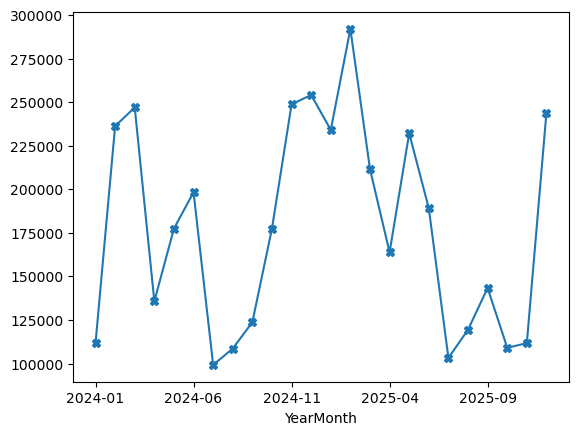

In [204]:
monthly_revenue=df.groupby('YearMonth')['revenue'].mean().plot(kind='line',marker='X')

##### Key Insights: Monthly Average Revenue Time Series Trend

* **Multi-Year Holiday Peaks:** Average revenue per campaign shows prominent multi-year peaks around year-end transitions, hitting a global maximum near **January 2025** alongside strong late-year rallies in **2024** and **2025**.
* **Consistent Summer Lulls:** Mid-year performance drops sharply across both years, reaching distinct local troughs in **mid-2024** and **mid-2025** (~$103k), confirming a strong annual summer slowdown.
* **Q1/Early Spring Volatility:** Both 2024 and 2025 demonstrate early-year volatility, marked by strong post-holiday/early-spring surges (e.g., **March 2024** and **May 2025**) before falling into mid-summer dips.

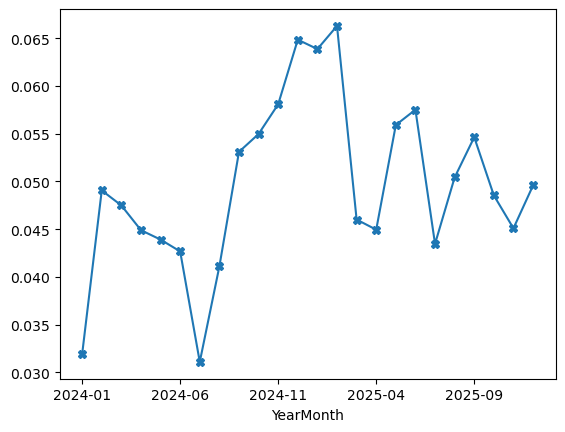

In [205]:
monthly_CVR=df.groupby('YearMonth')['CVR'].mean().plot(kind='line',marker='X')

##### Key Insights: Monthly Average CVR Time Series Trend

* **Late 2024 Conversion Peak:** Average conversion rate experienced an extended high-efficiency run in late 2024, peaking around **December 2024 / January 2025** (~6.6%), proving exceptional user conversion intent during that holiday period.
* **Mid-Year Troughs:** CVR experiences significant seasonal drops mid-year, hitting local lows in **mid-2024**  and **mid-2025**, showing that summer audience click-to-buy intent is consistently weaker.
* **Moderate 2025 Rebound:** While 2025 saw recovery surges in springand early fall (~5.5%), overall CVR levels stabilized slightly lower than the late 2024 peak, settling around ~4.5%–5.0% in late 2025.

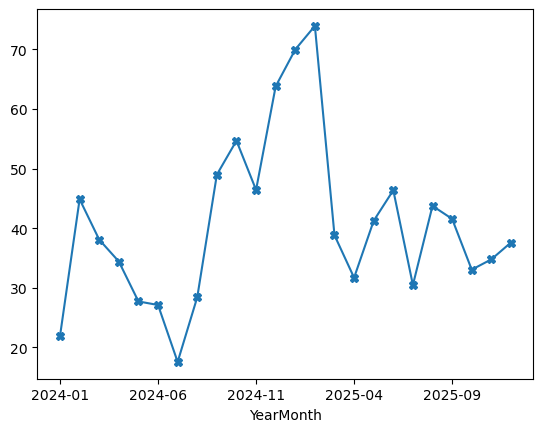

In [206]:
monthly_ROAS=df.groupby('YearMonth')['ROAS'].mean().plot(kind='line',marker='X')

##### Key Insights: Monthly Average ROAS Time Series Trend

* **Late 2024 Efficiency Peak:** Average Return on Ad Spend reached an all-time high in **late 2024 / early 2025** (~74x), capstone to a massive, sustained growth period in Q4 2024.
* **Mid-Year Efficiency Troughs:** Severe local dips occur mid-year, with **mid-2024** hitting the lowest return of the series and **mid-2025** experiencing a secondary dip (~30.5x).
* **Normalized Baseline in 2025:** Following the late 2024 peak, ROAS stabilized into a steady, less volatile band throughout 2025 (~30x–46x range), maintaining a higher baseline than early 2024.

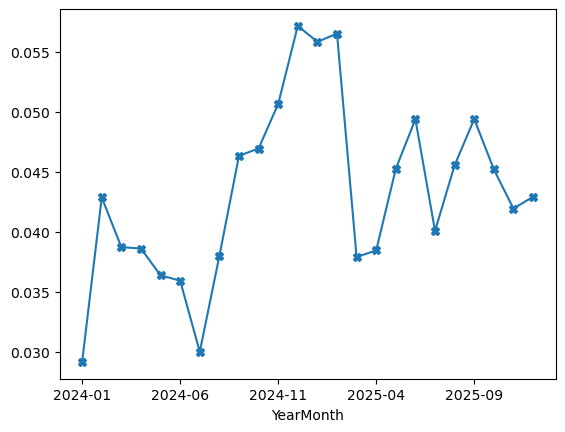

In [207]:
monthly_CTR=df.groupby('YearMonth')['CTR'].mean().plot(kind='line',marker='X')

##### Key Insights: Monthly Average CTR Time Series Trend

* **Late 2024 Engagement Peak:** Average click-through rate reached its annual maximum in **late 2024 / early 2025** (~5.7%), following continuous growth throughout H2 2024.
* **Mid-Year Troughs:** CTR exhibits significant seasonal dips mid-year, hitting local lows in **mid-2024**  and **mid-2025** (~4.0%), confirming lower click engagement during summer months.
* **Cyclical Spring & Fall Recoveries:** Both years show strong post-trough rebounds—surging sharply in spring (e.g., **May 2025** at ~4.9%) and early fall (e.g., **September 2025** at ~4.95%).

In [180]:
channel_campaign_revenue_pivot=df.pivot_table(values='revenue',
               index='channel_type',
               columns='campaign_type',
               aggfunc='sum',
               fill_value=0)
channel_campaign_revenue_pivot

campaign_type,Brand Awareness,Flash Sale,Lead Generation,Product Launch,Remarketing,Seasonal
channel_type,,,,,,
Display,320340075,2596779683,0,1790166651,1537997054,3065317684
Owned,674445764,1691761219,1582066908,2218572777,3698463368,6810011142
Search,193577794,0,1145348108,0,3352302198,1466533503
Social,1099225068,1867292976,9672302926,1537339214,12044170042,7297850966
Traditional,776382506,3393699955,2896080813,3638072944,7322107318,4325040586
Video,289946493,965424313,0,0,0,2136542399


##### Key Insights: Revenue by Channel & Campaign Type Matrix

* **Top Revenue Synergy:** The single highest revenue generator is **Social + Remarketing**, closely followed by **Social + Seasonal** and **Owned + Seasonal**.
* **Strongest All-Rounder Channel:** **Social Media** dominates performance across almost every campaign category, consistently yielding top-tier returns in both retargeting and seasonal efforts.
* **Underperforming Pairings:** **Video** yields the lowest revenue across almost all campaign types, with **Video + Brand Awareness** (~289M) generating the single lowest output in the dataset.

In [182]:
audience_channel_roas=df.pivot_table(values='ROAS',index='channel_type',columns='audience_segment',
                                        aggfunc='sum',fill_value=0)
audience_channel_roas

audience_segment,Corporate,Fitness Enthusiasts,Gamers,Parents,Students,Young Professionals
channel_type,,,,,,
Display,101538.475299,4.137430e+05,207312.588021,4.269236e+05,3.135787e+05,6.174059e+05
Owned,167465.771388,6.714736e+05,328401.997529,6.687481e+05,4.976512e+05,9.828291e+05
Search,73483.973502,2.794390e+05,135095.551905,2.900327e+05,2.272747e+05,4.197724e+05
Social,389854.565301,1.531228e+06,788168.147479,1.558899e+06,1.161374e+06,2.312442e+06
Traditional,242555.707129,9.460248e+05,474937.145459,9.379483e+05,7.152430e+05,1.390913e+06
Video,44776.773947,1.755449e+05,88369.975661,1.768847e+05,1.362805e+05,2.633671e+05


##### Key Insights: ROAS by Channel & Audience Segment Matrix

* **Top Performing Synergy:** **Social + Young Professionals** achieves the highest cumulative ROAS by a wide margin (~2.31M), outperforming all other channel-audience combinations.
* **Dominant Distribution Channel:** **Social Media** yields the highest aggregate ROAS across *every single audience segment* (ranging from ~390k for Corporate to ~2.31M for Young Professionals).
* **Underperforming Pairings:** **Video** yields the lowest efficiency across all segments, with **Video + Corporate** (~44.8k) generating the single lowest cumulative ROAS in the dataset.

In [183]:
state_campaign_revenue=df.pivot_table(values='revenue',index='state',columns='campaign_type',
                                        aggfunc='sum',fill_value=0)
state_campaign_revenue

campaign_type,Brand Awareness,Flash Sale,Lead Generation,Product Launch,Remarketing,Seasonal
state,,,,,,
Delhi,480025416,1462594564,2172616011,1307277471,4030626708,3537576807
Karnataka,472866482,1485656861,2175180850,1298684310,3965693939,3554805469
Maharashtra,952810428,3003538715,4345906189,2621439601,8021063196,7169315398
Tamil Nadu,489875681,1534728505,2222135844,1327880367,3989512653,3662424759
Telangana,482989762,1527474406,2207072233,1313824521,3998466047,3604509523
West Bengal,475349931,1500965095,2172887628,1315045316,3949677437,3572664324


##### Key Insights: Revenue by State & Campaign Type Matrix

* **Top Revenue Region:** **Maharashtra** generates the highest revenue across all campaign types by a significant margin, led by its **Remarketing** and **Seasonal** campaigns.
* **Consistent Top Campaign Performers:** Across all states (Delhi, Karnataka, Maharashtra, Tamil Nadu, Telangana, West Bengal), **Remarketing** and **Seasonal** consistently rank as the top 2 revenue-generating campaign types.
* **Balanced Regional Distribution:** Outside of Maharashtra's market lead, performance across the other 5 states is remarkably uniform, with each state generating nearly identical revenue tiers per campaign type (e.g., ~$47M–$48M for Brand Awareness).

In [208]:
df.to_csv('../data/processed/master_dataset_cleaned.csv', index=False, sep=';')